# Marketing

                orders  sessions  conversion_rate
social_media    129710  15816226         0.008201
direct           51951   6571549         0.007905
paid_search     141652  19598271         0.007228
referral         64565   9476845         0.006813
organic_search  181495  27196976         0.006673
email_campaign   77572  12792670         0.006064


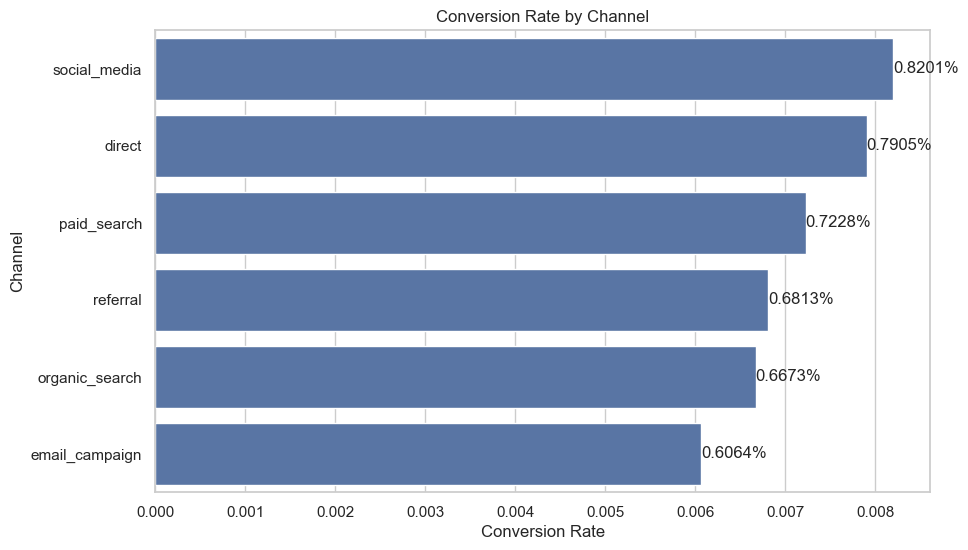

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# Load data
orders = pd.read_csv("data/orders.csv")
traffic = pd.read_csv("data/web_traffic.csv")

orders_by_source = orders.groupby("order_source").size().rename("orders")

traffic_by_source = traffic.groupby("traffic_source")["sessions"].sum().rename("sessions")

df = pd.concat([orders_by_source, traffic_by_source], axis=1)


# CONVERSION RATE
df["conversion_rate"] = df["orders"] / df["sessions"]

# Sort
df = df.sort_values("conversion_rate", ascending=False)

print(df)

# Visualization
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x=df["conversion_rate"],
    y=df.index
)

# %
for i, v in enumerate(df["conversion_rate"]):
    ax.text(v, i, f"{v:.4%}", va='center')

plt.title("Conversion Rate by Channel")
plt.xlabel("Conversion Rate")
plt.ylabel("Channel")

plt.show()

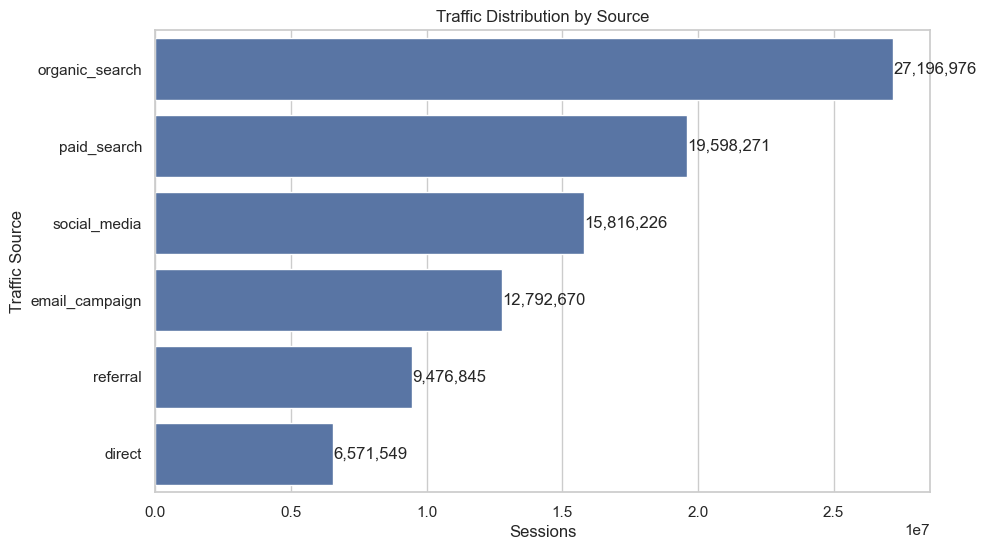

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

traffic = pd.read_csv("data/web_traffic.csv")

traffic_by_source = traffic.groupby("traffic_source")["sessions"].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))

ax = sns.barplot(
    x=traffic_by_source.values,
    y=traffic_by_source.index
)

for i, v in enumerate(traffic_by_source.values):
    ax.text(v, i, f"{v:,.0f}", va='center')

plt.title("Traffic Distribution by Source")
plt.xlabel("Sessions")
plt.ylabel("Traffic Source")

plt.show()

C:\Users\nguye\AppData\Local\Temp\ipykernel_21432\1180758276.py:18: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  (traffic_agg["sessions"][i], traffic_agg["bounce_rate"][i]))


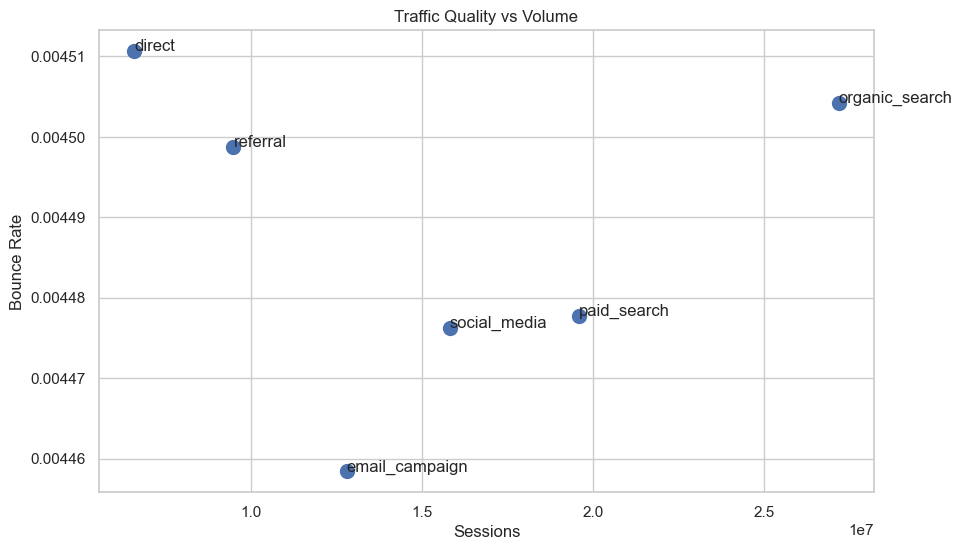

In [3]:
traffic = pd.read_csv("data/web_traffic.csv")

traffic_agg = traffic.groupby("traffic_source").agg({
    "sessions": "sum",
    "bounce_rate": "mean"
}).sort_values("sessions", ascending=False)

plt.figure(figsize=(10,6))

scatter = plt.scatter(
    traffic_agg["sessions"],
    traffic_agg["bounce_rate"],
    s=100
)

for i, txt in enumerate(traffic_agg.index):
    plt.annotate(txt, 
                 (traffic_agg["sessions"][i], traffic_agg["bounce_rate"][i]))

plt.xlabel("Sessions")
plt.ylabel("Bounce Rate")
plt.title("Traffic Quality vs Volume")

plt.show()

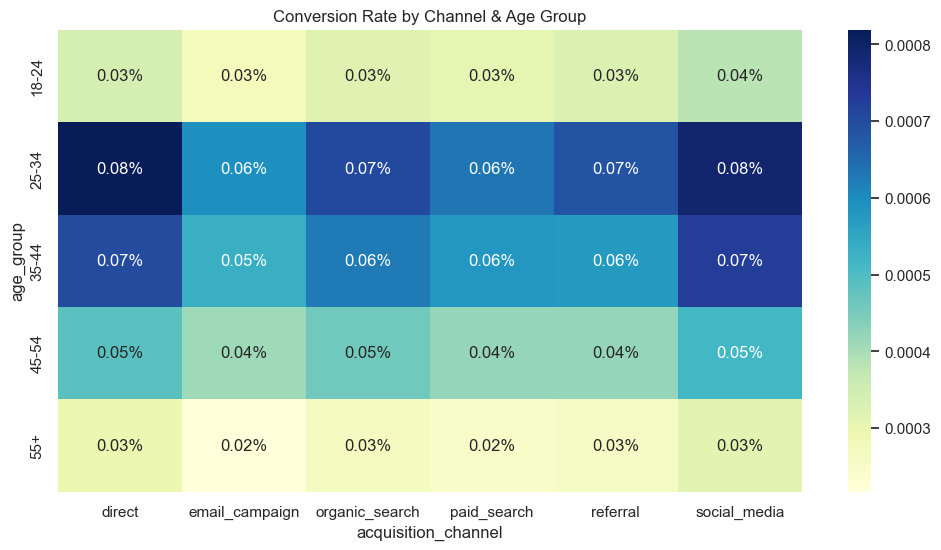

In [ ]:
# 🎯 3. Conversion + Customer Segmentation

orders = pd.read_csv("data/orders.csv")
customers = pd.read_csv("data/customers.csv")
traffic = pd.read_csv("data/web_traffic.csv")

df = orders.merge(
    customers[["customer_id", "age_group", "gender", "acquisition_channel"]],
    on="customer_id",
    how="left"
)


orders_seg = df.groupby(["acquisition_channel", "age_group", "gender"]).size().rename("orders")
traffic_seg = traffic.groupby("traffic_source")["sessions"].sum().rename("sessions")

# Map channel (important)
conversion = orders_seg.reset_index()
conversion = conversion.merge(
    traffic_seg,
    left_on="acquisition_channel",
    right_index=True,
    how="left"
)

conversion["conversion_rate"] = conversion["orders"] / conversion["sessions"]

conversion = conversion.dropna()
pivot = conversion.pivot_table(
    index="age_group",
    columns="acquisition_channel",
    values="conversion_rate"
)

plt.figure(figsize=(12,6))

sns.heatmap(
    pivot,
    annot=True,
    fmt=".2%",
    cmap="YlGnBu"
)

plt.title("Conversion Rate by Channel & Age Group")
plt.show()